
**Asignatura:** Teoria de la Distribucion y Probabilidad
**Ciclo:** Segundo Ciclo  
**Grupo:** E  

**Integrantes:**
-   Matias Romero
-   Joaquin Moscol
-   Selena Castillo
-   Irvin Armijos
-   Jefferson Sarango

# **Tarea 1: Configuracion del Entorno**

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import randint, norm, binom, uniform
import seaborn as sns

# Configuracion de estilo
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 11

print("Entorno configurado correctamente")


Entorno configurado correctamente


# **Tarea 2: Variable Aleatoria Discreta - Lanzamiento de Dado**

Caso: X = resultado del lanzamiento de un dado justo.

2.	Defina la variable aleatoria y su PMF:

In [3]:
# Variable aleatoria: resultado de un dado
# X puede tomar valores: 1, 2, 3, 4, 5, 6

# Valores posibles
x_valores = np.array([1, 2, 3, 4, 5, 6])

# PMF: cada valor tiene probabilidad 1/6
pmf_dado = np.array([1/6, 1/6, 1/6, 1/6, 1/6, 1/6])

print("Valores de X:", x_valores)
print("PMF p(x):", pmf_dado)
print("Suma de probabilidades:", np.sum(pmf_dado))


Valores de X: [1 2 3 4 5 6]
PMF p(x): [0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]
Suma de probabilidades: 0.9999999999999999


3.	Visualice la PMF:

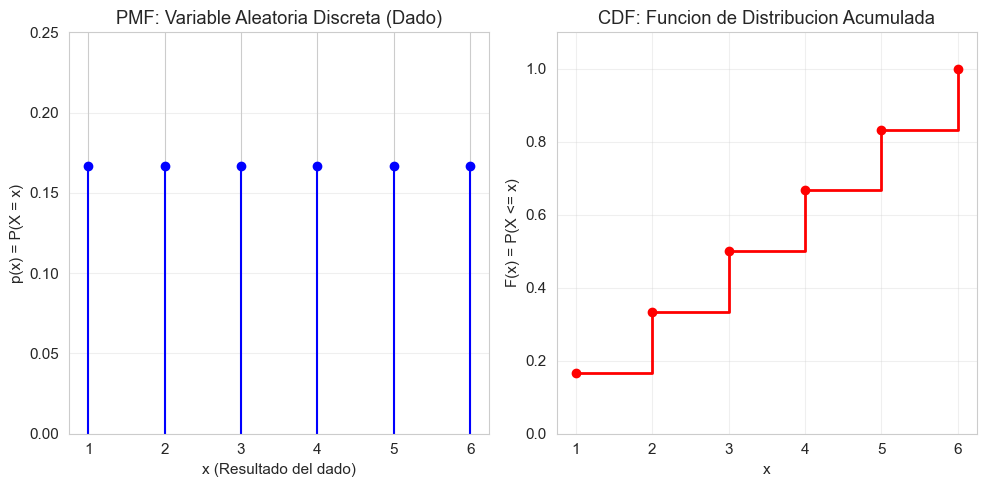

In [4]:
# Visualizacion de la PMF
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.stem(x_valores, pmf_dado, basefmt=" ", linefmt='b-', markerfmt='bo')
plt.xlabel('x (Resultado del dado)')
plt.ylabel('p(x) = P(X = x)')
plt.title('PMF: Variable Aleatoria Discreta (Dado)')
plt.xticks(x_valores)
plt.ylim(0, 0.25)
plt.grid(axis='y', alpha=0.3)

# CDF
cdf_dado = np.cumsum(pmf_dado)
plt.subplot(1, 2, 2)
plt.step(x_valores, cdf_dado, where='post', color='red', linewidth=2)
plt.scatter(x_valores, cdf_dado, color='red', zorder=5)
plt.xlabel('x')
plt.ylabel('F(x) = P(X <= x)')
plt.title('CDF: Funcion de Distribucion Acumulada')
plt.xticks(x_valores)
plt.ylim(0, 1.1)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


4.	Calcule probabilidades especificas:

In [ ]:
# a) P(X = 4)
prob_4 = pmf_dado[x_valores == 4][0]
print(f"P(X = 4) = {prob_4:.4f}")

# b) P(X <= 3) usando CDF
prob_menor_3 = cdf_dado[x_valores == 3][0]
print(f"P(X <= 3) = {prob_menor_3:.4f}")

# c) P(2 <= X <= 5)
prob_entre_2_5 = cdf_dado[x_valores == 5][0] - cdf_dado[x_valores == 1][0]
print(f"P(2 <= X <= 5) = {prob_entre_2_5:.4f}")


P(X = 4) = 0.1667
P(X <= 3) = 0.5000
P(2 <= X <= 5) = 0.6667


# **Tarea 3: Variable Aleatoria Continua - Distribucion Normal**

Caso: X = tiempo de respuesta de un servidor (ms), distribuido normalmente con mu = 200 y sigma = 30.

5.	Defina la distribucion y visualice la PDF:

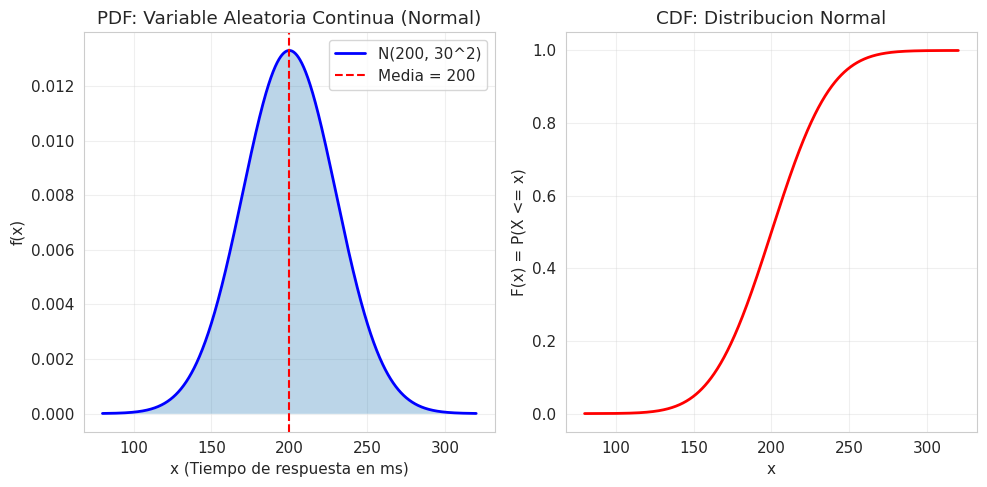

In [ ]:
# Parametros de la distribucion normal
mu = 200  # media
sigma = 30  # desviacion estandar

# Crear la distribucion
dist_normal = norm(loc=mu, scale=sigma)

# Rango de valores para graficar
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)

# PDF
pdf_normal = dist_normal.pdf(x)

# Visualizacion
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(x, pdf_normal, 'b-', linewidth=2, label=f'N({mu}, {sigma}^2)')
plt.fill_between(x, pdf_normal, alpha=0.3)
plt.axvline(mu, color='red', linestyle='--', label=f'Media = {mu}')
plt.xlabel('x (Tiempo de respuesta en ms)')
plt.ylabel('f(x)')
plt.title('PDF: Variable Aleatoria Continua (Normal)')
plt.legend()
plt.grid(alpha=0.3)

# CDF
cdf_normal = dist_normal.cdf(x)
plt.subplot(1, 2, 2)
plt.plot(x, cdf_normal, 'r-', linewidth=2)
plt.xlabel('x')
plt.ylabel('F(x) = P(X <= x)')
plt.title('CDF: Distribucion Normal')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


6.	Calcule probabilidades:

In [ ]:
# a) P(X <= 180)
prob_menor_180 = dist_normal.cdf(180)
print(f"P(X <= 180) = {prob_menor_180:.4f} ({prob_menor_180*100:.2f}%)")

# b) P(X > 250)
prob_mayor_250 = 1 - dist_normal.cdf(250)
print(f"P(X > 250) = {prob_mayor_250:.4f} ({prob_mayor_250*100:.2f}%)")

# c) P(170 <= X <= 230)
prob_entre = dist_normal.cdf(230) - dist_normal.cdf(170)
print(f"P(170 <= X <= 230) = {prob_entre:.4f} ({prob_entre*100:.2f}%)")

# d) Percentil 95
p95 = dist_normal.ppf(0.95)
print(f"\nPercentil 95: {p95:.2f} ms")
print(f"El 95% de los tiempos de respuesta son menores a {p95:.2f} ms")


P(X <= 180) = 0.2525 (25.25%)
P(X > 250) = 0.0478 (4.78%)
P(170 <= X <= 230) = 0.6827 (68.27%)

Percentil 95: 249.35 ms
El 95% de los tiempos de respuesta son menores a 249.35 ms


# **Tarea 4: Comparacion Visual PMF vs PDF**

7.	Cree una visualizacion comparativa:

In [ ]:
# Comparacion PMF vs PDF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Variable Discreta (Dado)
axes[0].stem(x_valores, pmf_dado, basefmt=" ", linefmt='b-', markerfmt='bo')
axes[0].set_xlabel('x')
axes[0].set_ylabel('p(x)')
axes[0].set_title('VARIABLE DISCRETA\nPMF: Funcion de Masa de Probabilidad')
axes[0].set_xticks(x_valores)
axes[0].set_ylim(0, 0.25)
axes[0].grid(axis='y', alpha=0.3)

# Anotaciones
axes[0].annotate('Probabilidad en\npuntos especificos', xy=(3, 1/6), xytext=(4.5, 0.2),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 fontsize=10, color='red')

# Variable Continua (Normal)
axes[1].plot(x, pdf_normal, 'b-', linewidth=2)
axes[1].fill_between(x, pdf_normal, alpha=0.3)
axes[1].set_xlabel('x')
axes[1].set_ylabel('f(x)')
axes[1].set_title('VARIABLE CONTINUA\nPDF: Funcion de Densidad de Probabilidad')
axes[1].grid(alpha=0.3)

# Anotaciones
axes[1].annotate('Probabilidad = Area\nbajo la curva', xy=(200, norm.pdf(200, 200, 30)), xytext=(250, 0.01),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 fontsize=10, color='red')

plt.suptitle('Comparacion: Variable Aleatoria Discreta vs Continua', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


***8.	En su grupo, identifique 5 variables aleatorias en diferentes areas de la UNL:***

•	Biblioteca

•	Cafeteria

•	Laboratorios

•	Estacionamiento

•	Aulas de clase

***9.	Para cada variable, determine:***

•	Tipo: Discreta / Continua

•	Posibles valores que puede tomar

•	Distribucion de probabilidad esperada (si se puede inferir)

***10.	Complete la tabla de registro:***


In [6]:
import pandas as pd
from tabulate import tabulate

# Variables identificadas para la UNL
variables_unl = [
    {
        'Área': 'Biblioteca',
        'Variable': 'Libros solicitados (8-9 AM)',
        'Tipo': 'Discreta',
        'Valores': '{0, 1, 2, ..., n}',
        'Distribución': 'Poisson'
    },
    {
        'Área': 'Cafetería',
        'Variable': 'Gasto monetario ($ USD)',
        'Tipo': 'Discreta',
        'Valores': '0.50 a 3.00',
        'Distribución': 'Empírica / Normal'
    },
    {
        'Área': 'Laboratorios',
        'Variable': 'Computadoras operativas',
        'Tipo': 'Discreta',
        'Valores': '{0, 1, 2, ..., C}',
        'Distribución': 'Binomial'
    },
    {
        'Área': 'Estacionamiento',
        'Variable': 'Motos parqueadas (10 AM)',
        'Tipo': 'Discreta',
        'Valores': '{0, 1, 2, ..., C}',
        'Distribución': 'Uniforme Discreta'
    },
    {
        'Área': 'Aulas de clase',
        'Variable': 'Estatura (2do Ciclo)',
        'Tipo': 'Continua',
        'Valores': '[1.40, 2.00] m',
        'Distribución': 'Normal'
    }
]

# Crear el DataFrame
df = pd.DataFrame(variables_unl)

# Imprimir con formato de rejilla (grid) para añadir los separadores
print(tabulate(df, headers='keys', tablefmt='grid', showindex=False))

+-----------------+-----------------------------+----------+-------------------+-------------------+
| Área            | Variable                    | Tipo     | Valores           | Distribución      |
+=================+=============================+==========+===================+===================+
| Biblioteca      | Libros solicitados (8-9 AM) | Discreta | {0, 1, 2, ..., n} | Poisson           |
+-----------------+-----------------------------+----------+-------------------+-------------------+
| Cafetería       | Gasto monetario ($ USD)     | Discreta | 0.50 a 3.00       | Empírica / Normal |
+-----------------+-----------------------------+----------+-------------------+-------------------+
| Laboratorios    | Computadoras operativas     | Discreta | {0, 1, 2, ..., C} | Binomial          |
+-----------------+-----------------------------+----------+-------------------+-------------------+
| Estacionamiento | Motos parqueadas (10 AM)    | Discreta | {0, 1, 2, ..., C} | Uniforme D

11.	Modifique el codigo de la Tarea 3 para representar una variable de su eleccion:


***11.	Modifique el codigo de la Tarea 3 para representar una variable de su eleccion:***

•	Opcion A: Distribución Bernoulli (lanzamiento de moneda)

•	Opcion B: Distribución Uniforme discreta

•	Opcion C: Distribución Binomial

•	Genere las gráficas PMF/PDF y CDF para su distribución seleccionada.

•	Calcule al menos 3 probabilidades especificas e interprete los resultados


**Distribución Elegida:** Binomial

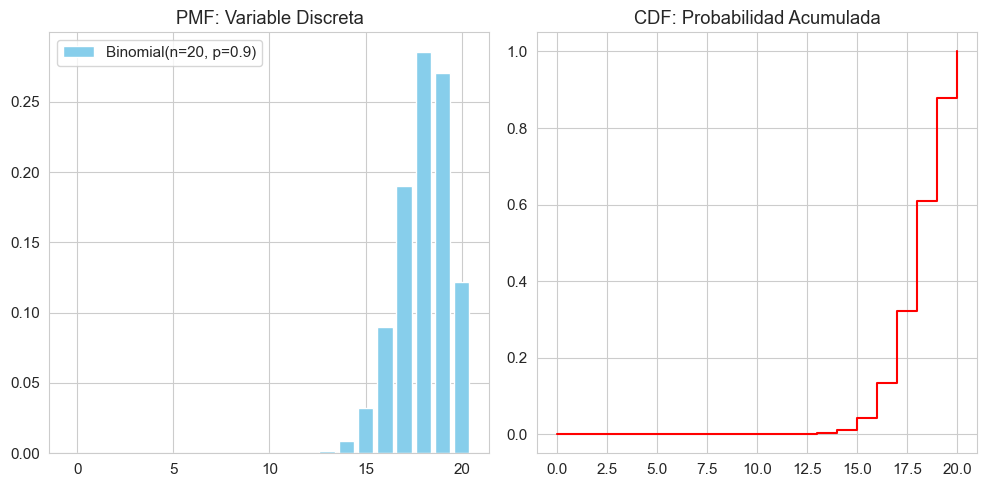

P(X = 18): 0.2852
P(X <= 15): 0.0432
P(X > 17): 0.6769


In [7]:
from scipy.stats import binom
import matplotlib.pyplot as plt
import numpy as np

# Parámetros: n=ensayos (computadoras), p=probabilidad de éxito
n, p = 20, 0.9
dist_binom = binom(n, p)

# Rango de valores (0 a 20 computadoras)
x = np.arange(0, n + 1)

# PMF y CDF
pmf_v = dist_binom.pmf(x)
cdf_v = dist_binom.cdf(x)

# Visualización
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.bar(x, pmf_v, color='skyblue', label=f'Binomial(n={n}, p={p})')
plt.title('PMF: Variable Discreta')
plt.legend()

plt.subplot(1, 2, 2)
plt.step(x, cdf_v, where='post', color='red')
plt.title('CDF: Probabilidad Acumulada')
plt.tight_layout()
plt.show()

# Probabilidades
print(f"P(X = 18): {dist_binom.pmf(18):.4f}")      # Exacta
print(f"P(X <= 15): {dist_binom.cdf(15):.4f}")    # Acumulada menor
print(f"P(X > 17): {1 - dist_binom.cdf(17):.4f}") # Acumulada mayor

# 7. Preguntas de Control

### 1. ¿Cuál es la diferencia fundamental entre una variable aleatoria discreta y una continua?**

Una variable aleatoria discreta toma valores contables y separados, generalmente números enteros (por ejemplo: 0, 1, 2, 3…). Estos valores provienen de procesos de conteo.
En cambio, una variable aleatoria continua puede tomar infinitos valores dentro de un intervalo de números reales (por ejemplo: 1.2, 3.75, 4.001…). Estas variables provienen de mediciones, como tiempo, peso o temperatura.

### 2. ¿Por qué en una variable continua $P(X = x) = 0$ para cualquier valor específico $x$?
En una variable continua existen infinitos valores posibles dentro de un intervalo. Debido a esto, la probabilidad de que la variable tome exactamente un valor específico es prácticamente nula.
Por ello, en variables continuas la probabilidad se calcula sobre intervalos (por ejemplo: P(a ≤ X ≤ b)) y no en valores puntuales.

### 3. Explique la relación entre la PMF/PDF y la CDF. ¿Cómo se obtiene una de la otra?
Densidad de Probabilidad (PDF) para variables continuas describen la probabilidad puntual o la densidad en un punto específico del dominio. Por otro lado, la Función de Distribución Acumulada (CDF) representa la acumulación de esas probabilidades desde el límite inferior hasta un valor determinado x. 
La relación entre ellas es de acumulación o cambio:
**Para obtener la CDF:** En el caso discreto, se realiza una suma de los valores de la PMF hasta el punto de interés. En el caso continuo, se integra la función PDF desde el límite inferior hasta el valor deseado.
**Para obtener la PMF o PDF desde la CDF:** Se realiza el proceso inverso; en variables discretas se calcula la diferencia entre valores consecutivos de la CDF, mientras que en variables continuas se deriva la función CDF.

### 4. Una variable aleatoria $X$ representa el número de estudiantes que llegan tarde a clase. ¿Es $X$ discreta o continua? Justifique.
La variable aleatoria X es de naturaleza discreta. La justificación técnica radica en que el número de estudiantes es una variable cuyos valores provienen de un proceso de conteo y pertenecen al conjunto de los números enteros positivos. 
No es posible que la variable tome valores fraccionarios o decimales dentro de un intervalo; por ejemplo, es físicamente imposible que lleguen "1.5 estudiantes" o "2.75 estudiantes" tarde a una sesión. Al ser unidades enteras e indivisibles que se pueden enumerar uno a uno, la variable cumple estrictamente con la definición de variable aleatoria discreta. 

### 5. Calcule $P(X = 5)$ para una variable continua con PDF $f(x) = 2x$ en $[0,1]$. Explique su respuesta.
P(X = 5) = 0.
Esto se debe a que en variables continuas la probabilidad en un punto específico es 0, y además 5 no pertenece al intervalo [0,1].

### 6. Dibuje aproximadamente la CDF de una variable discreta que toma valores {1, 2, 3} con probabilidades {0.3, 0.5, 0.2}.
La función de distribución acumulada (CDF) es una función escalonada:
F(x) = 0 si x < 1
F(x) = 0.3 si 1 ≤ x < 2
F(x) = 0.8 si 2 ≤ x < 3
F(x) = 1 si x ≥ 3
Gráfica de la CDF:
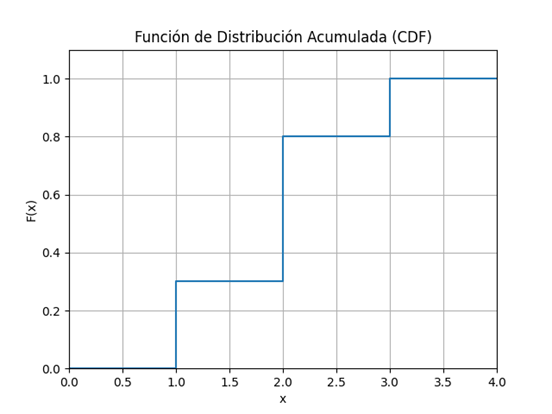
### 7. Identifique una variable aleatoria continua en el contexto de la carrera de Computación y justifique porque es continua.
Identifique una variable aleatoria continua en el contexto de la carrera de Computación y justifique porque es continua
Una variable aleatoria continua en el contexto de la carrera de Computación puede ser el tiempo de ejecución de un programa. Esta se considera continua porque puede tomar cualquier valor real dentro de un intervalo, por ejemplo 1.2 segundos, 1.25 segundos o 1.253 segundos, dependiendo de la precisión con la que se mida. A diferencia de las variables discretas, no está limitada a valores enteros, sino que puede variar de forma fluida y con infinitos posibles valores dentro de un rango determinado.
